# Moiré analysis: the run as a 4D-STEM dataset

Notebook 04 turned the NNO run into images: line = last scan pulse, column = µs since the pulse ÷ 15 µs dwell,
and one count per cluster in a ring of the detector. The ADF and BF images show a moiré: a square lattice
with a period of ~90 probe positions, with a few dots inside each cell.

Here the clusters keep their **position on the detector**, so every probe position gets a whole diffraction
pattern: a 4D dataset (scan row, scan column, detector row, detector column). The steps:

1. The scan and the BF disk, as in notebook 04 (section 1).
2. How many probe positions to add up per pattern: the time bin (section 2).
3. One pass over the run into two 4D cubes (section 3).
4. Where the zero beam is in each pattern, and aligning on it (section 4).
5. Deconvolve the zero beam out of the position-averaged pattern: the Bragg reflections of two crystals, rotated
   against each other (section 5), and the same two crystals in the Fourier transform of the image (section 6).
6. Map the rotation of each crystal, and the twist between them, across the image (section 7).

In [1]:
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numba
import numpy as np
from matplotlib.colors import LogNorm
from plot_style import AQUA, DIVERGING, ORANGE, SEQUENTIAL, no_grid
from scipy.ndimage import gaussian_filter, sobel
from scipy.ndimage import shift as shift_image
from scipy.optimize import curve_fit, least_squares
from scipy.special import erfc

from kronos.cluster import cluster_tables, label_events, summarize_clusters
from kronos.events import concat, event_columns, fine_steps, take
from kronos.sort import merge_sort, time_order

%matplotlib ipympl

## 1. The scan and the BF disk

The scan geometry is the one measured in notebook 04: one LVDS pulse per line, 1024 lines, and 1024 probe
positions per line at a fixed 15 µs dwell from each line's own pulse. The pulses are read again here,
and eight lines from the middle of the frame are sorted and clustered to find the BF disk.

In [2]:
run_directory = Path('/Users/7c2/Desktop/Projects/TimePix/data/2026_10_08_NNO_200kV_15mrad')
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
work_directory = project_root / 'outputs' / run_directory.name
files = sorted((run_directory / 'raw').glob('*.h5'))

WIDTH, HEIGHT = 448, 512
TICK_S = 25e-9  # one toa tick
DWELL_US, N_COLUMNS = 15, 1024  # notebook 04, section 8
BIN_TICKS = 40  # ticks per µs
DT_MAX = 1  # ticks, notebook 02
PAD = 1 << 16  # ticks: merge_sort's max_disorder

pulse_list = []
for path in files:
    with h5py.File(path, 'r') as h5:
        pulse_list.append(h5['lvds_timestamp'][:].astype(np.int64))
pulses = np.sort(np.concatenate(pulse_list))  # line starts, in fine units (1/128 tick)
n_lines = len(pulses)
dwell_fine = DWELL_US * BIN_TICKS * fine_steps


def first_row(toa, t):
    # Row near the first toa >= t, by bisection on an HDF5 toa column sorted up to small disorder.
    lo, hi = 0, len(toa)
    while hi - lo > 1000:
        middle = (lo + hi) // 2
        lo, hi = (middle, hi) if toa[middle] < t else (lo, middle)
    return lo


SAMPLE_FIRST, SAMPLE_LINES = 500, 8
t_start, t_stop = pulses[SAMPLE_FIRST] // fine_steps, pulses[SAMPLE_FIRST + SAMPLE_LINES] // fine_steps
chunks = []
for path in files:
    with h5py.File(path, 'r') as h5:
        rows = slice(first_row(h5['toa'], t_start - PAD), first_row(h5['toa'], t_stop + PAD))
        chunks.append({name: h5[name][rows] for name in event_columns})
events = concat(chunks)
events = take(events, (events['toa'] >= t_start) & (events['toa'] < t_stop))
events = take(events, time_order(events['toa']))
clusters = summarize_clusters(events, label_events(events['x'], events['y'], events['toa'], DT_MAX))
del events, chunks

sample_fine = clusters.toa.to_numpy() * fine_steps
sample_line = np.searchsorted(pulses, sample_fine, 'right') - 1
sample_column = (sample_fine - pulses[sample_line]) // dwell_fine
in_scan = sample_column < N_COLUMNS
cluster_image, _, _ = np.histogram2d(clusters.y, clusters.x, bins=(HEIGHT, WIDTH), range=((0, HEIGHT), (0, WIDTH)))

rows_grid, cols_grid = np.indices(cluster_image.shape)
disk_level = np.median(cluster_image[cluster_image > np.percentile(cluster_image, 99)])  # top 1 % of pixels: inside the disk
disk = cluster_image > disk_level / 2
center_x, center_y = cols_grid[disk].mean(), rows_grid[disk].mean()
bf_radius = np.sqrt(disk.sum() / np.pi)
per_position = in_scan.sum() / (SAMPLE_LINES * N_COLUMNS)
print(f'{len(clusters):,} clusters in {SAMPLE_LINES} lines; {per_position:.0f} electrons per probe position')
print(f'BF disk: center ({center_x:.1f}, {center_y:.1f}) px, radius {bf_radius:.1f} px')

21,222,073 clusters in 8 lines; 2389 electrons per probe position
BF disk: center (203.9, 257.2) px, radius 54.8 px


## 2. The time bin: how many probe positions per pattern

One probe position is 15 µs of beam and ~2400 electrons, spread over a pattern of ~10⁵ pixels: most pixels
get nothing. A usable pattern adds up a block of b × b probe positions, b lines × (b · 15 µs) along the line,
so it holds 2400 b² electrons. The price is resolution in the scan, and the scale that sets it is the finest
strong periodicity of the image: the brightest spot in the Fourier transform of notebook 04's ADF image.

strongest periodicity: 23.6 probe positions (the moiré cell is ~90)


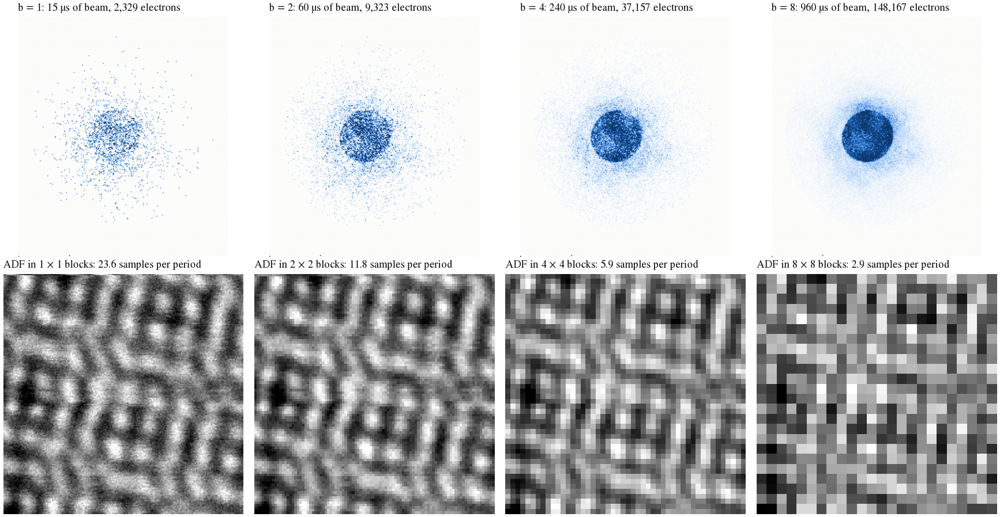

In [3]:
adf_full = np.load(work_directory / 'scan_images.npz')['adf'].astype(np.float32)  # notebook 04, 1024 x 1024
power = np.abs(np.fft.rfft2(adf_full - adf_full.mean())) ** 2
frequency_y, frequency_x = np.meshgrid(np.fft.fftfreq(N_COLUMNS), np.fft.rfftfreq(N_COLUMNS), indexing='ij')
spot = np.unravel_index(np.where(np.hypot(frequency_x, frequency_y) > 1 / 200, power, 0).argmax(), power.shape)  # skip the slow background
finest_period = 1 / np.hypot(frequency_x[spot], frequency_y[spot])
print(f'strongest periodicity: {finest_period:.1f} probe positions (the moiré cell is ~90)')

BLOCKS = [1, 2, 4, 8]
CROP = 192
x_sample, y_sample = clusters.x.to_numpy(), clusters.y.to_numpy()
fig, axes = plt.subplots(2, len(BLOCKS), figsize=(16, 8.4))
for ax_pattern, ax_image, b in zip(axes[0], axes[1], BLOCKS):
    block = in_scan & (sample_line - SAMPLE_FIRST < b) & (sample_column >= 512) & (sample_column < 512 + b)
    pattern, _, _ = np.histogram2d(y_sample[block], x_sample[block], bins=(HEIGHT // 2, WIDTH // 2), range=((0, HEIGHT), (0, WIDTH)))
    ax_pattern.imshow(pattern, origin='lower', cmap=SEQUENTIAL, vmin=0, vmax=max(np.percentile(pattern, 99.5), 1))
    ax_pattern.set(title=f'b = {b}: {b * b * DWELL_US} µs of beam, {block.sum():,} electrons')
    no_grid(ax_pattern)
    binned = adf_full[:CROP, :CROP].reshape(CROP // b, b, CROP // b, b).sum((1, 3))
    ax_image.imshow(binned, cmap='gray', vmin=np.percentile(binned, 0.5), vmax=np.percentile(binned, 99.5))
    ax_image.set(title=f'ADF in {b} × {b} blocks: {finest_period / b:.1f} samples per period')
    no_grid(ax_image)
plt.tight_layout()
plt.show()

Top: patterns from the sample (detector in 2 × 2 pixel bins). Bottom: the top-left 192 × 192 probe positions of
the ADF image (about two moiré cells), binned the same way.

* At b = 1 a pattern is a scatter of single electrons; even inside the BF disk most pixels are empty.
  At b = 4 (37 k electrons) the disk and the diffuse scattering around it are clear.
* The strongest periodicity is not the ~90-position moiré cell but the ~24-position fringes inside it (the lattice
  planes of the two crystals, sections 5–6).
  b = 4 samples it ~6 times per period. At b = 8 it is under 3 samples per period, close to the
  Nyquist limit, and the image breaks up into aliasing.

So **b = 4**: one pattern per 4 × 4 probe positions, 4 lines × 60 µs (240 µs of beam), a 256 × 256 scan of
38 k-electron patterns. Section 3 checks that the differences between patterns at this binning are above shot noise.

## 3. One pass into two 4D cubes

The same streaming pass as notebook 04 (`merge_sort` → `cluster_tables`), but each cluster is added to two
cubes instead of the rings:

* `disk_cube[256, 256, 64, 64]`: the 4D dataset at the time bin of section 2, for the zero beam: one pattern per
  4 × 4 probe positions, in 2 × 2 pixel bins over ±64 px around the disk center (the disk radius is 55 px). 540 MB.
* `tile_cube[32, 32, 320, 320]`: one pattern per tile of 32 × 32 probe positions, at full detector resolution over
  ±160 px. The Bragg disks of the two crystals are only a few pixels apart (section 5), so this cube trades scan
  resolution for detector resolution. 210 MB.

Electrons during the flyback (column ≥ 1024) are dropped. The pass takes ~8 minutes, and the cubes are cached in `outputs/`.

In [4]:
SCAN_BIN, TILE = 4, 32  # probe positions per pattern (each way) in the two cubes
DISK_BIN, DISK_HALF = 2, 64  # disk_cube: 2 x 2 detector px, +-64 px around the disk center
TILE_HALF = 160  # tile_cube: 1 px, +-160 px
disk_origin = np.array([round(center_x) - DISK_HALF, round(center_y) - DISK_HALF], np.float64)  # detector (x, y) of the cube's corner
tile_origin = np.array([round(center_x) - TILE_HALF, round(center_y) - TILE_HALF], np.float64)
n_scan, n_tiles = N_COLUMNS // SCAN_BIN, N_COLUMNS // TILE


@numba.njit
def bin_patterns(toa, x, y, pulses, dwell_fine, scan_bin, disk_origin, disk_bin, tile, tile_origin, disk_cube, tile_cube):
    # Count each cluster into disk_cube[line // scan_bin, column // scan_bin, detector row, detector column] and
    # tile_cube[line // tile, column // tile, ...], column = time since the line's pulse // dwell.
    # Clusters before the first pulse, in the flyback, or outside a cube's detector window are skipped by that cube.
    n_cols, disk_size = disk_cube.shape[1:3]
    tile_size = tile_cube.shape[2]
    for i in range(len(toa)):
        t = toa[i] * fine_steps
        line = np.searchsorted(pulses, t, 'right') - 1
        column = (t - pulses[line]) // dwell_fine
        if line < 0 or column >= n_cols * scan_bin:
            continue
        u, v = x[i] - disk_origin[0], y[i] - disk_origin[1]
        if u >= 0 and v >= 0 and u < disk_size * disk_bin and v < disk_size * disk_bin:
            disk_cube[line // scan_bin, column // scan_bin, int(v) // disk_bin, int(u) // disk_bin] += 1
        u, v = x[i] - tile_origin[0], y[i] - tile_origin[1]
        if u >= 0 and v >= 0 and u < tile_size and v < tile_size:
            tile_cube[line // tile, column // tile, int(v), int(u)] += 1


disk_path, tile_path = work_directory / 'disk_cube.npy', work_directory / 'tile_cube.npy'
if tile_path.exists():
    disk_cube, tile_cube = np.load(disk_path), np.load(tile_path)
else:
    disk_cube = np.zeros((n_scan, n_scan, 2 * DISK_HALF // DISK_BIN, 2 * DISK_HALF // DISK_BIN), np.uint16)
    tile_cube = np.zeros((n_tiles, n_tiles, 2 * TILE_HALF, 2 * TILE_HALF), np.uint16)
    start = time.perf_counter()
    for table in cluster_tables(merge_sort(files), DT_MAX):
        args = (pulses, dwell_fine, SCAN_BIN, disk_origin, DISK_BIN, TILE, tile_origin, disk_cube, tile_cube)
        bin_patterns(table.toa.to_numpy(), table.x.to_numpy(), table.y.to_numpy(), *args)
    print(f'{(time.perf_counter() - start) / 60:.1f} min')
    np.save(disk_path, disk_cube)
    np.save(tile_path, tile_cube)
print(f'disk_cube {disk_cube.shape}: {disk_cube.sum((2, 3), dtype=np.int64).mean():,.0f} electrons per pattern in the zero-beam window')
print(f'tile_cube {tile_cube.shape}: {tile_cube.sum((2, 3), dtype=np.int64).mean() / 1e6:.1f} M electrons per tile, largest bin {tile_cube.max()}')

disk_cube (256, 256, 64, 64): 26,201 electrons per pattern in the zero-beam window
tile_cube (32, 32, 320, 320): 2.4 M electrons per tile, largest bin 249


**Checks.** A virtual BF image (0–48 px) made from `disk_cube`, compared with notebook 04's BF image binned 4 × 4. Then
the binning test promised in section 2: for every detector bin of the zero beam, the variance of its counts across the
scan divided by the variance shot noise alone would give (the mean). A ratio above 1 means the pattern really changes
across the scan.

virtual BF vs notebook 04 binned 4 x 4: correlation 0.9999


variance / shot noise per 2 x 2 px bin, median inside the disk (< 48 px): 1.2


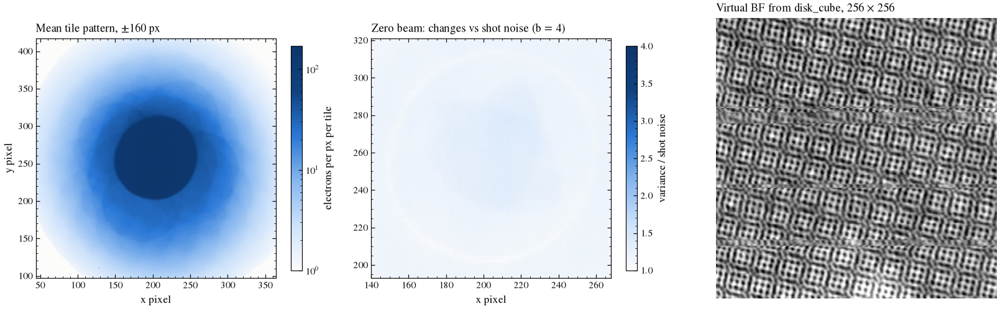

In [5]:
disk_size = disk_cube.shape[2]
disk_axis = disk_origin[0] + DISK_BIN * (np.arange(disk_size) + 0.5), disk_origin[1] + DISK_BIN * (np.arange(disk_size) + 0.5)
disk_kx, disk_ky = np.meshgrid(*disk_axis)  # detector (x, y) of each bin center
disk_r = np.hypot(disk_kx - center_x, disk_ky - center_y)
bf_virtual = disk_cube[..., disk_r < 48].sum(-1, dtype=np.float64)
bf_full = np.load(work_directory / 'scan_images.npz')['bf'].astype(np.float64)  # notebook 04, 1024 x 1024
bf_reference = bf_full.reshape(n_scan, SCAN_BIN, n_scan, SCAN_BIN).sum((1, 3))
print(f'virtual BF vs notebook 04 binned 4 x 4: correlation {np.corrcoef(bf_virtual.ravel(), bf_reference.ravel())[0, 1]:.4f}')

mean_disk = disk_cube.mean((0, 1), dtype=np.float64)
variance = np.zeros_like(mean_disk)
for row in range(n_scan):
    variance += ((disk_cube[row] - mean_disk) ** 2).sum(0)
excess = variance / (n_scan * n_scan) / np.maximum(mean_disk, 1e-9)  # variance / Poisson variance
print(f'variance / shot noise per 2 x 2 px bin, median inside the disk (< 48 px): {np.median(excess[disk_r < 48]):.1f}')

mean_tile = tile_cube.mean((0, 1), dtype=np.float64)
fig, (ax_mean, ax_excess, ax_bf) = plt.subplots(1, 3, figsize=(15, 4.6))
tile_extent = (tile_origin[0], tile_origin[0] + 2 * TILE_HALF, tile_origin[1], tile_origin[1] + 2 * TILE_HALF)
shown = ax_mean.imshow(np.maximum(mean_tile, 1), origin='lower', cmap=SEQUENTIAL, norm=LogNorm(), extent=tile_extent)
fig.colorbar(shown, ax=ax_mean, shrink=0.8, label='electrons per px per tile')
ax_mean.set(title='Mean tile pattern, ±160 px', xlabel='x pixel', ylabel='y pixel')
ax_mean.grid(False)
disk_extent = (disk_origin[0], disk_origin[0] + 2 * DISK_HALF, disk_origin[1], disk_origin[1] + 2 * DISK_HALF)
shown = ax_excess.imshow(excess, origin='lower', cmap=SEQUENTIAL, vmin=1, vmax=4, extent=disk_extent)
fig.colorbar(shown, ax=ax_excess, shrink=0.8, label='variance / shot noise')
ax_excess.set(title='Zero beam: changes vs shot noise (b = 4)', xlabel='x pixel')
ax_excess.grid(False)
ax_bf.imshow(bf_virtual, cmap='gray', vmin=np.percentile(bf_virtual, 0.5), vmax=np.percentile(bf_virtual, 99.5))
ax_bf.set(title='Virtual BF from disk_cube, 256 × 256')
no_grid(ax_bf)
plt.tight_layout()
plt.show()

* The virtual BF image from `disk_cube` matches notebook 04's (r = 0.9999): the same clusters, put at the same probe positions.
* Per 2 × 2-pixel bin of the zero beam, the variance across the scan is 1.2× the shot noise (median). At b = 4 the patterns
  change from one probe position to the next by about the shot noise per bin, summed over ~2400 bins in the disk.

## 4. Aligning the zero beam

Where is the zero beam in each pattern? Two estimates from `disk_cube`:

* **center of mass** of the counts within 68 px of the nominal center (the disk plus a margin);
* **the disk edge**: smooth the pattern, take the gradient magnitude (large only at the edge), and find the shift
  that best matches it to the edge of an ideal disk of the measured radius (cross-correlation, sub-pixel by a parabola
  through the peak).

They need not agree. A rigid shift of the disk moves both, but intensity moving around *inside* the disk moves
only the center of mass.

 center of mass: rms x 1.15 px, y 1.17 px; neighbor-to-neighbor scatter 0.58 px (an upper bound on the noise)
      disk edge: rms x 0.19 px, y 0.19 px; neighbor-to-neighbor scatter 0.09 px (an upper bound on the noise)


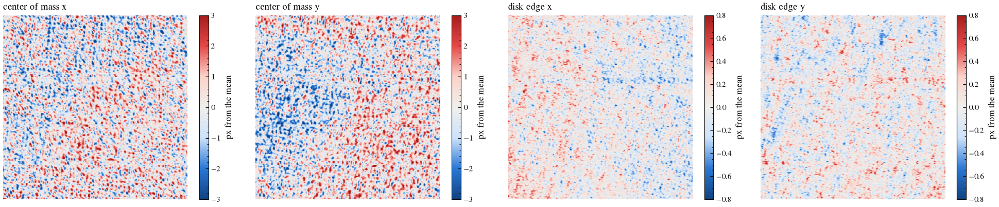

In [6]:
COM_RADIUS = 68  # px: the disk (55 px) plus a margin
EDGE_SMOOTH = 1.0  # bins (2 px): Gaussian smoothing before the edge filter
MAX_SHIFT = 5  # bins (10 px): search range for the edge
inside = disk_r < COM_RADIUS
ideal_disk = gaussian_filter((disk_r < bf_radius).astype(np.float64), EDGE_SMOOTH)
edge_template = np.conj(np.fft.rfft2(np.hypot(sobel(ideal_disk, 0), sobel(ideal_disk, 1))))
search = slice(disk_size // 2 - MAX_SHIFT, disk_size // 2 + MAX_SHIFT + 1)  # shifts -MAX_SHIFT..MAX_SHIFT after fftshift

com_x, com_y, edge_x, edge_y = (np.empty((n_scan, n_scan)) for _ in range(4))
scan_index = np.arange(n_scan)
for row in range(n_scan):
    counts = disk_cube[row].astype(np.float32)
    com_x[row] = counts[:, inside] @ disk_kx[inside] / counts[:, inside].sum(1)
    com_y[row] = counts[:, inside] @ disk_ky[inside] / counts[:, inside].sum(1)
    smoothed = gaussian_filter(counts, (0, EDGE_SMOOTH, EDGE_SMOOTH))
    edges = np.hypot(sobel(smoothed, 1), sobel(smoothed, 2))
    match = np.fft.fftshift(np.fft.irfft2(np.fft.rfft2(edges) * edge_template, s=(disk_size, disk_size)), axes=(1, 2))[:, search, search]
    iy, ix = np.unravel_index(match.reshape(n_scan, -1).argmax(1), match.shape[1:])
    iy, ix = np.clip(iy, 1, 2 * MAX_SHIFT - 1), np.clip(ix, 1, 2 * MAX_SHIFT - 1)
    peak, up, down, left, right = (match[scan_index, iy + dy, ix + dx] for dy, dx in [(0, 0), (-1, 0), (1, 0), (0, -1), (0, 1)])
    edge_y[row] = center_y + DISK_BIN * (iy - MAX_SHIFT + 0.5 * (up - down) / (up - 2 * peak + down))
    edge_x[row] = center_x + DISK_BIN * (ix - MAX_SHIFT + 0.5 * (left - right) / (left - 2 * peak + right))

for name, x_map, y_map in [('center of mass', com_x, com_y), ('disk edge', edge_x, edge_y)]:
    scatter = np.hypot(np.diff(x_map, axis=1).std(), np.diff(y_map, axis=1).std()) / 2  # neighbors differ by noise * sqrt(2), per axis
    print(
        f'{name:>15}: rms x {x_map.std():.2f} px, y {y_map.std():.2f} px; neighbor-to-neighbor scatter {scatter:.2f} px (an upper bound on the noise)'
    )

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4))
for ax, (title, image, limit) in zip(
    axes,
    [
        ('center of mass x', com_x - com_x.mean(), 3),
        ('center of mass y', com_y - com_y.mean(), 3),
        ('disk edge x', edge_x - edge_x.mean(), 0.8),
        ('disk edge y', edge_y - edge_y.mean(), 0.8),
    ],
):
    shown = ax.imshow(image, cmap=DIVERGING, vmin=-limit, vmax=limit)
    fig.colorbar(shown, ax=ax, shrink=0.8, label='px from the mean')
    ax.set(title=title)
    no_grid(ax)
plt.tight_layout()
plt.show()

* The **center of mass** wanders by ±1.2 px rms, in a pattern that follows the moiré lattice.
* The **disk edge** moves by only ±0.2 px rms, with at most 0.09 px of noise; the largest shift is about 1 px. The descan
  is nearly perfect. What is left is a slow drift of a fraction of a pixel across the field, and streaks along the fast scan.
* So the center-of-mass signal is not the disk moving. It is intensity moving around **inside a disk that stays put**.
  Aligning on the center of mass would shift disks that did not move.

The patterns are therefore aligned on the **edge**. Each tile pattern of `tile_cube` is shifted (sub-pixel, bilinear) by
the mean edge offset of its 8 × 8 patterns. That matters below: the lattice angles are measured around the zero beam,
and 0.2 px at r = 30 px is 0.4°.

In [7]:
mean_x, mean_y = edge_x.mean(), edge_y.mean()
blocks = TILE // SCAN_BIN  # disk_cube patterns per tile, each way
tile_shift_x = mean_x - edge_x.reshape(n_tiles, blocks, n_tiles, blocks).mean((1, 3))  # px that move each tile's disk onto the mean
tile_shift_y = mean_y - edge_y.reshape(n_tiles, blocks, n_tiles, blocks).mean((1, 3))
tiles_aligned = np.empty(tile_cube.shape, np.float32)
for row in range(n_tiles):
    for col in range(n_tiles):
        tiles_aligned[row, col] = shift_image(tile_cube[row, col].astype(np.float32), (tile_shift_y[row, col], tile_shift_x[row, col]), order=1)
print(f'zero beam at ({mean_x:.2f}, {mean_y:.2f}); tile shifts up to {np.hypot(tile_shift_x, tile_shift_y).max():.2f} px')

zero beam at (204.22, 257.83); tile shifts up to 0.39 px


## 5. Deconvolving the zero beam: the Bragg disks of two crystals

With a 15 mrad convergence angle, every Bragg reflection is a disk as large as the zero beam (radius 55 px), and
the disks overlap: the reflections here lie ~30 px apart. Within a single pattern the overlapping disks interfere,
and the interference depends on the probe position. Averaged over many probe positions, the **position-averaged
CBED** (PACBED) loses the interference and is, to a good approximation, a sum of copies of the zero-beam disk, one
centered on each reflection **g**, plus a diffuse background:

PACBED(k) ≈ Σ_g I_g · disk(k − g) + diffuse.

Deconvolving the disk (the **probe**, here the aperture function) out of the PACBED leaves the reflections themselves,
I_g δ(k − g), as in a parallel-beam diffraction pattern. This is **probe deconvolution**. Two ways to do it:

* **Richardson–Lucy** deconvolution, the version for Poisson counts.
* **Edge matching**: everything about where a disk is sits in its sharp edge. So match the edge of the zero beam (an
  ideal disk of the fitted radius and edge width) against the edge map of the PACBED. This is the template matching used
  to find Bragg disks in 4D-STEM, and it ignores the diffuse background.

The PACBED here is the whole scan: the sum of the aligned tiles.

In [8]:
PACBED_SMOOTH = 1.0  # px: Gaussian smoothing before the edge filter
RL_ITERATIONS = 200
pacbed = tiles_aligned.sum((0, 1), dtype=np.float64)
tile_kx, tile_ky = np.meshgrid(*(tile_origin[a] + np.arange(2 * TILE_HALF) + 0.5 - (mean_x, mean_y)[a] for a in (0, 1)))  # px from the zero beam
tile_r = np.hypot(tile_kx, tile_ky)
print(f'PACBED: {pacbed.sum() / 1e9:.2f} G electrons')

# The zero-beam disk: radius and edge width from an erfc step fitted to the radial profile, on a linear background.
quarter = (tile_r * 4).astype(int).ravel()  # 0.25 px radial bins
radial = np.bincount(quarter, pacbed.ravel()) / np.maximum(np.bincount(quarter), 1)
radius_axis = (np.arange(len(radial)) + 0.5) / 4
near_edge = (radius_axis > 44) & (radius_axis < 66)


def edge_step(r, base, slope, radius, width, step):
    return base + slope * (r - radius) + step * 0.5 * erfc((r - radius) / (np.sqrt(2) * width))


start_values = (radial[near_edge].min(), 0, bf_radius, 1.5, np.ptp(radial[near_edge]))
(_, _, disk_radius, edge_width, _), _ = curve_fit(edge_step, radius_axis[near_edge], radial[near_edge], p0=start_values)
print(f'zero-beam disk: radius {disk_radius:.2f} px, edge width (Gaussian sigma) {edge_width:.2f} px')
kernel = gaussian_filter((np.hypot(*(np.indices(pacbed.shape) - TILE_HALF)) < disk_radius).astype(np.float64), edge_width)
kernel /= kernel.sum()
kernel_ft = np.fft.rfft2(np.fft.ifftshift(kernel))
kernel_edges_ft = np.conj(np.fft.rfft2(np.fft.ifftshift(np.hypot(*(sobel(gaussian_filter(kernel, PACBED_SMOOTH), axis) for axis in (0, 1))))))

# Richardson-Lucy: multiplicative updates that keep the estimate positive.
deconvolved = np.full(pacbed.shape, pacbed.mean())
for _ in range(RL_ITERATIONS):
    blurred = np.fft.irfft2(np.fft.rfft2(deconvolved) * kernel_ft, s=pacbed.shape)
    deconvolved *= np.fft.irfft2(np.fft.rfft2(pacbed / np.maximum(blurred, 1e-9)) * np.conj(kernel_ft), s=pacbed.shape)


def bragg_spots(pattern):
    # Edge matching: the pattern's edge map cross-correlated with the zero beam's edge, keeping the sharp peaks (one per disk).
    edges = np.hypot(*(sobel(gaussian_filter(pattern, PACBED_SMOOTH), axis) for axis in (0, 1)))
    match = np.fft.irfft2(np.fft.rfft2(edges) * kernel_edges_ft, s=pattern.shape)
    return np.maximum(match - gaussian_filter(match, 5), 0)


pacbed_edges = np.hypot(*(sobel(gaussian_filter(pacbed, PACBED_SMOOTH), axis) for axis in (0, 1)))
bragg = bragg_spots(pacbed)

PACBED: 2.46 G electrons
zero-beam disk: radius 54.60 px, edge width (Gaussian sigma) 1.58 px


To read off the two crystals, fit the spot map with a model: two square lattices, each with a spacing |g| and an
angle θ, with a Gaussian spot of one width at every (100), (110) and (200) reflection, and one weight per family. The
same fit is used on the image FFT in section 6 and on every tile in section 7.

crystal A: |g| = 29.43 ± 0.01 px at 71.77 ± 0.03° (mod 90°); weights (100) 1.00, (110) 0.60, (200) 0.64
crystal B: |g| = 29.56 ± 0.03 px at 58.10 ± 0.05° (mod 90°); weights (100) 0.45, (110) 0.23, (200) 0.36
twist B − A: -13.67°


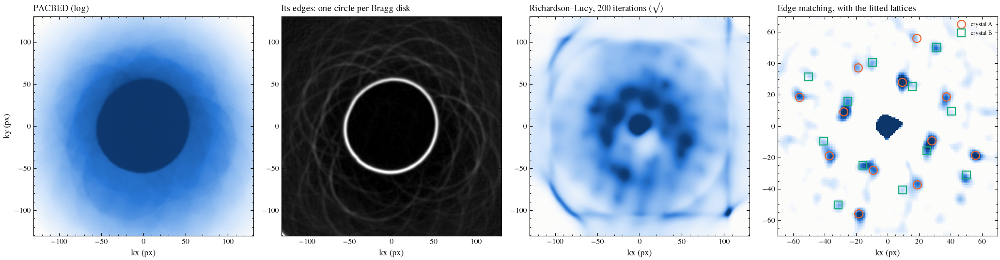

In [9]:
FAMILIES = [
    np.array(family, np.float64)
    for family in ([(1, 0), (0, 1), (-1, 0), (0, -1)], [(1, 1), (-1, 1), (1, -1), (-1, -1)], [(2, 0), (0, 2), (-2, 0), (0, -2)])
]
FAMILY_NAMES = ['(100)', '(110)', '(200)']


def lattice_spots(g, theta_degrees):
    # (family, x, y) of every reflection of a square lattice with spacing g at angle theta.
    theta = np.radians(theta_degrees)
    rotation = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return [(f, x, y) for f, family in enumerate(FAMILIES) for x, y in g * family @ rotation.T]


def strongest_direction(image, kx, ky, ring, avoid=None):
    # Spacing and angle of the brightest pixel within the ring (r_min, r_max), at least 6 degrees (mod 90) from avoid.
    r, angle = np.hypot(kx, ky), np.degrees(np.arctan2(ky, kx))
    allowed = (r > ring[0]) & (r < ring[1])
    if avoid is not None:
        allowed &= abs((angle - avoid + 45) % 90 - 45) > 6
    best = np.unravel_index(np.where(allowed, image, -np.inf).argmax(), image.shape)
    return r[best], angle[best]


def fit_two_lattices(image, kx, ky, start_a, start_b):
    # Least-squares fit of image (kx, ky: each pixel's coordinates) with a background plus two square lattices.
    # Parameters: background, g_a, theta_a, g_b, theta_b, spot width, then a weight per (lattice, family).
    def model(p):
        out = np.full(image.shape, p[0])
        for lattice in range(2):
            for f, x, y in lattice_spots(p[1 + 2 * lattice], p[2 + 2 * lattice]):
                out += p[6 + 3 * lattice + f] * np.exp(-((kx - x) ** 2 + (ky - y) ** 2) / (2 * p[5] ** 2))
        return out

    start_p = [0, *start_a, *start_b, 2] + [image.max() / 2] * 6
    lower = [-np.inf, 0, -360, 0, -360, 0.3] + [0] * 6
    fit = least_squares(lambda p: (model(p) - image).ravel(), start_p, bounds=(lower, np.inf))
    covariance = np.linalg.pinv(fit.jac.T @ fit.jac) * (fit.fun**2).sum() / (fit.fun.size - len(start_p))
    return fit.x, np.sqrt(np.diag(covariance))


FIT_HALF = 70  # px around the zero beam: (100), (110) and (200) reflections
middle = np.unravel_index(tile_r.argmin(), tile_r.shape)
fit_window = (slice(middle[0] - FIT_HALF, middle[0] + FIT_HALF + 1), slice(middle[1] - FIT_HALF, middle[1] + FIT_HALF + 1))
kx_det, ky_det = tile_kx[fit_window], tile_ky[fit_window]
outside_zero_beam = np.hypot(kx_det, ky_det) > 20
bragg_fit = np.where(outside_zero_beam, bragg[fit_window], 0)
start_a = strongest_direction(bragg_fit, kx_det, ky_det, (20, 36))
start_b = (start_a[0], strongest_direction(bragg_fit, kx_det, ky_det, (2 * start_a[0] - 8, 2 * start_a[0] + 8), avoid=start_a[1])[1])
diffraction_fit, diffraction_error = fit_two_lattices(bragg_fit, kx_det, ky_det, start_a, start_b)
for lattice, name in enumerate('AB'):
    g, theta = diffraction_fit[1 + 2 * lattice], diffraction_fit[2 + 2 * lattice]
    weights = ', '.join(
        f'{family} {w / diffraction_fit[6]:.2f}' for family, w in zip(FAMILY_NAMES, diffraction_fit[6 + 3 * lattice : 9 + 3 * lattice])
    )
    print(
        f'crystal {name}: |g| = {g:.2f} ± {diffraction_error[1 + 2 * lattice]:.2f} px at {theta % 90:.2f} ± {diffraction_error[2 + 2 * lattice]:.2f}° (mod 90°); weights {weights}'
    )
diffraction_twist = (diffraction_fit[4] - diffraction_fit[2] + 45) % 90 - 45  # a square lattice's angle is defined mod 90°
print(f'twist B − A: {diffraction_twist:+.2f}°')

ZOOM_HALF = 130
zoom = (slice(middle[0] - ZOOM_HALF, middle[0] + ZOOM_HALF + 1), slice(middle[1] - ZOOM_HALF, middle[1] + ZOOM_HALF + 1))
zoom_extent = (-ZOOM_HALF - 0.5, ZOOM_HALF + 0.5) * 2
fig, axes = plt.subplots(1, 4, figsize=(19, 5.2))
panels = [
    ('PACBED (log)', np.log10(np.maximum(pacbed[zoom], 1)), SEQUENTIAL),
    ('Its edges: one circle per Bragg disk', (pacbed_edges / gaussian_filter(np.maximum(pacbed, 1), 6))[zoom], 'gray'),
    (f'Richardson–Lucy, {RL_ITERATIONS} iterations (√)', np.sqrt(deconvolved[zoom]), SEQUENTIAL),
    ('Edge matching, with the fitted lattices', bragg[zoom], SEQUENTIAL),
]
beyond_zero_beam = tile_r[zoom] > 20
for ax, (title, image, cmap) in zip(axes, panels):
    inner = image[beyond_zero_beam]  # color scale from outside the zero beam
    ax.imshow(image, origin='lower', cmap=cmap, extent=zoom_extent, vmin=np.percentile(inner, 1), vmax=np.percentile(inner, 99.8))
    ax.set(title=title, xlabel='kx (px)')
    ax.grid(False)
axes[0].set_ylabel('ky (px)')
axes[3].set(xlim=(-FIT_HALF, FIT_HALF), ylim=(-FIT_HALF, FIT_HALF))
axes[3].images[0].set_clim(0, np.percentile(bragg_fit, 99.8))  # scale to the spots, not the ring at twice the disk radius
for lattice, (color, marker) in enumerate([(ORANGE, 'o'), (AQUA, 's')]):
    spots = np.array([(x, y) for _, x, y in lattice_spots(diffraction_fit[1 + 2 * lattice], diffraction_fit[2 + 2 * lattice])])
    axes[3].plot(*spots.T, marker, mfc='none', mec=color, ms=11, mew=1.5, label=f'crystal {"AB"[lattice]}')
axes[3].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

* The PACBED (left) looks like one bright disk on a halo. Its edge map shows what is underneath: many circles with the
  zero beam's radius, one per Bragg disk, crossing each other.
* Richardson–Lucy turns the zero beam into one sharp spot and the halo into a ring of broad spots. Those are the reflections,
  blurred by diffuse scattering that a disk deconvolution cannot remove. Edge matching gives sharp spots (right), and two
  square lattices account for all of them.
* **Crystal A**: |g| = 29.4 px at 71.8°, with strong (100), (110) and (200) reflections. **Crystal B**: 29.6 px at 58.1°, the
  same spacing to 0.5 %, about half as bright, and **rotated by −13.7°** against A.
* The ± values are statistical only. The two crystals' (100) spots are just 7 px apart at r = 29 px and partly overlap, so the
  real uncertainty of the angles is closer to a degree.

## 6. The same two crystals in the image FFT

In real space each crystal's lattice planes make fringes in the image, so the Fourier transform of the image is a
second, independent view of the same reciprocal lattices: frequency in cycles per probe position instead of detector
pixels. The full-resolution BF image of notebook 04 (1024 × 1024 positions, Hann window) is fitted with the same model.

crystal A: period 23.93 probe positions at 7.17 ± 0.01° (mod 90°); weights (100) 1.00, (110) 0.23, (200) 0.00
crystal B: period 23.87 probe positions at 22.12 ± 0.01° (mod 90°); weights (100) 0.86, (110) 0.26, (200) 0.00
twist B − A: +14.95°; the moiré of the two (100) lattices: 91.8 probe positions
detector frame = scan frame mirrored, then rotated by 78.9° (mod 90°)


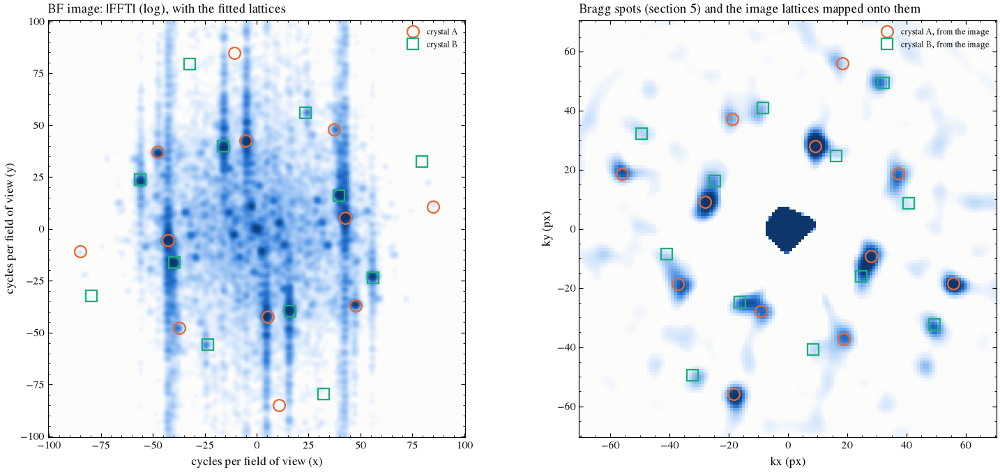

In [10]:
FFT_HALF = 100  # cycles per field of view: up to the (200) reflections
spectrum = np.abs(np.fft.fftshift(np.fft.fft2((bf_full - bf_full.mean()) * np.outer(np.hanning(N_COLUMNS), np.hanning(N_COLUMNS)))))
cycles = np.arange(-FFT_HALF, FFT_HALF + 1)  # cycles per field of view (1024 probe positions)
fx_img, fy_img = np.meshgrid(cycles, cycles)
amplitude = spectrum[N_COLUMNS // 2 - FFT_HALF : N_COLUMNS // 2 + FFT_HALF + 1, N_COLUMNS // 2 - FFT_HALF : N_COLUMNS // 2 + FFT_HALF + 1]
amplitude_fit = np.where(np.hypot(fx_img, fy_img) > 25, amplitude, 0)  # leave out the moiré and slower
image_start_a = strongest_direction(amplitude_fit, fx_img, fy_img, (25, 55))
image_start_b = (image_start_a[0], strongest_direction(amplitude_fit, fx_img, fy_img, (25, 55), avoid=image_start_a[1])[1])
image_fit, image_error = fit_two_lattices(amplitude_fit, fx_img, fy_img, image_start_a, image_start_b)
for lattice, name in enumerate('AB'):
    g, theta = image_fit[1 + 2 * lattice], image_fit[2 + 2 * lattice]
    weights = ', '.join(f'{family} {w / image_fit[6]:.2f}' for family, w in zip(FAMILY_NAMES, image_fit[6 + 3 * lattice : 9 + 3 * lattice]))
    print(
        f'crystal {name}: period {N_COLUMNS / g:.2f} probe positions at {theta % 90:.2f} ± {image_error[2 + 2 * lattice]:.2f}° (mod 90°); weights {weights}'
    )
image_twist = (image_fit[4] - image_fit[2] + 45) % 90 - 45
moire_period = N_COLUMNS / np.hypot(*np.subtract(lattice_spots(*image_fit[1:3])[0][1:], lattice_spots(*image_fit[3:5])[0][1:]))
print(f'twist B − A: {image_twist:+.2f}°; the moiré of the two (100) lattices: {moire_period:.1f} probe positions')

# Map the image's lattices onto the detector. Crystal A sets the scale and the rotation (with a mirror if the twist
# changes sign); crystal B then lands on the detector by the image's own twist, which tests the match.
mirror = np.sign(image_twist) != np.sign(diffraction_twist)
scale = diffraction_fit[1] / image_fit[1]  # detector px per cycle per field of view
frame_rotation = (diffraction_fit[2] - (-image_fit[2] if mirror else image_fit[2])) % 90
image_on_detector = [
    (scale * image_fit[1], diffraction_fit[2]),
    (scale * image_fit[3], diffraction_fit[2] + (-image_twist if mirror else image_twist)),
]
print(f'detector frame = scan frame {"mirrored, then " if mirror else ""}rotated by {frame_rotation:.1f}° (mod 90°)')

fig, (ax_fft, ax_both) = plt.subplots(1, 2, figsize=(14, 6.4))
shown = np.log10(gaussian_filter(amplitude, 1))  # light smoothing for display
ax_fft.imshow(
    shown,
    origin='lower',
    cmap=SEQUENTIAL,
    extent=(-FFT_HALF - 0.5, FFT_HALF + 0.5) * 2,
    vmin=np.percentile(shown, 50),
    vmax=np.percentile(shown, 99.95),
)
for lattice, (color, marker) in enumerate([(ORANGE, 'o'), (AQUA, 's')]):
    spots = np.array([(x, y) for _, x, y in lattice_spots(image_fit[1 + 2 * lattice], image_fit[2 + 2 * lattice])])
    ax_fft.plot(*spots.T, marker, mfc='none', mec=color, ms=11, mew=1.5, label=f'crystal {"AB"[lattice]}')
    detector_spots = np.array([(x, y) for _, x, y in lattice_spots(*image_on_detector[lattice])])
    ax_both.plot(*detector_spots.T, marker, mfc='none', mec=color, ms=11, mew=1.5, label=f'crystal {"AB"[lattice]}, from the image')
ax_fft.set(title='BF image: |FFT| (log), with the fitted lattices', xlabel='cycles per field of view (x)', ylabel='cycles per field of view (y)')
ax_fft.legend(loc='upper right', fontsize=8)
ax_fft.grid(False)
ax_both.imshow(
    bragg[fit_window], origin='lower', cmap=SEQUENTIAL, extent=(-FIT_HALF - 0.5, FIT_HALF + 0.5) * 2, vmin=0, vmax=np.percentile(bragg_fit, 99.8)
)
ax_both.set(title='Bragg spots (section 5) and the image lattices mapped onto them', xlabel='kx (px)', ylabel='ky (px)')
ax_both.legend(loc='upper right', fontsize=8)
ax_both.grid(False)
plt.tight_layout()
plt.show()

* The image shows **the same two lattices**: periods of 23.93 and 23.87 probe positions (equal to 0.3 %) at 7.2° and 22.1°, a
  **twist of +14.95°**. Their (100) difference vector predicts a moiré of 91.8 positions, the moiré cell of notebook 04 (90.2 and
  91.6 positions). So the ~24-position "dots" are lattice fringes of the two crystals, and the moiré is their beat.
* As in diffraction, crystal A is the stronger one (weights 1.00 vs 0.86).
* The twist is the same within ~1°: 15.0° in the image, 13.7° in diffraction. The image value is the more precise: its spots are
  sharp on a 1024-point transform and do not overlap.
* The **sign flips**. Taking A to be the brighter lattice in both, the detector frame is the scan frame **mirrored and rotated by
  79°** (mod 90°: a square lattice cannot tell 90° apart). The right panel uses exactly that: crystal A sets the scale and
  the rotation, and crystal B, placed by the image's own twist, falls on the B spots of the diffraction pattern. This
  scan-to-detector relation is what center-of-mass (DPC) or ptychographic analyses need.
* **Calibration.** 29.4 detector px correspond to 1 / 23.9 cycles per probe position. With the nominal 15 mrad at the disk edge
  (54.6 px, so 0.275 mrad per px), |g| = 8.1 mrad, d = λ / θ = 2.508 pm / 8.1 mrad = 3.1 Å, a probe step of 0.13 Å and a 13 nm
  field of view. If NNO is NdNiO₃ (pseudocubic 3.81 Å) and these are its (100) planes, the convergence semi-angle is 12.2 mrad
  rather than 15, the step 0.16 Å and the field 16 nm. The 15 mrad from the folder name is worth checking.

## 7. Mapping the rotation across the image

Both views can be made local.

* **Image: geometric phase analysis (GPA).** Keep only a small Gaussian neighborhood around one reflection **g** in
  the image FFT and transform back: the result is that reflection's fringes, a complex image A(r) e^{iφ(r)}. The phase
  gradient is the local wavevector, g + ∇φ/2π, so its direction is the local orientation of those lattice planes. Each
  crystal's rotation is the mean over its two (100) reflections, and the twist is B minus A. The Gaussian (σ = 3 cycles
  per field) is narrow enough to keep the two crystals apart (their (100) spots are 11 cycles apart). That sets the
  resolution: ~1024 / (2π · 3) ≈ 55 probe positions, about half a moiré cell. The FFT treats the image as periodic, so
  the phase is wrong near the borders; a 128-position frame is left out.
* **Diffraction: the fit of section 5 on tiles.** Sum the aligned `tile_cube` tiles 4 × 4 (128 × 128 probe positions,
  ~39 M electrons each), match edges, and fit the two lattices, starting from the PACBED fit. The detector angles are turned
  into scan-frame angles with the mirror and rotation of section 6.

The rotation maps show each crystal's angle minus its mean.

GPA twist (interior): mean +15.11°, rms 0.32°, 1–99 % +14.12 to +15.94°
crystal A (interior): rotation rms 0.22°; (100) vs (010) correlation -0.34, shear + noise rms 0.30°
crystal B (interior): rotation rms 0.28°; (100) vs (010) correlation -0.47, shear + noise rms 0.44°


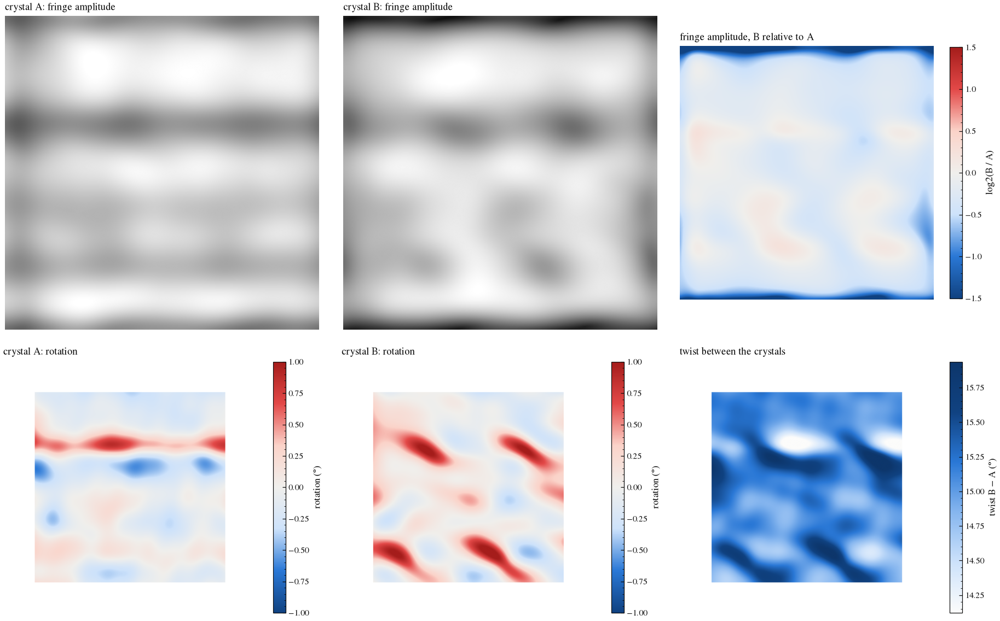

In [11]:
GPA_SIGMA = 3  # cycles per field of view: Gaussian mask around each reflection
GPA_MARGIN = 128  # probe positions at the borders where the periodic FFT corrupts the phase
spectrum_raw = np.fft.fft2(bf_full - bf_full.mean())
frequency = np.fft.fftfreq(N_COLUMNS) * N_COLUMNS  # cycles per field of view
frequency_x, frequency_y = np.meshgrid(frequency, frequency)
gpa_amplitude, gpa_rotation, gpa_deviations = [], [], []
for lattice in range(2):
    g, theta = image_fit[1 + 2 * lattice], image_fit[2 + 2 * lattice]
    deviations, amplitudes = [], []
    for _, gx, gy in lattice_spots(g, theta)[:2]:  # its (100) and (010) reflections
        fringes = np.fft.ifft2(spectrum_raw * np.exp(-((frequency_x - gx) ** 2 + (frequency_y - gy) ** 2) / (2 * GPA_SIGMA**2)))
        d_row, d_col = np.gradient(fringes)
        local_gx = (np.conj(fringes) * d_col).imag / abs(fringes) ** 2 * N_COLUMNS / (2 * np.pi)  # cycles per field of view
        local_gy = (np.conj(fringes) * d_row).imag / abs(fringes) ** 2 * N_COLUMNS / (2 * np.pi)
        deviations.append((np.degrees(np.arctan2(local_gy, local_gx) - np.arctan2(gy, gx)) + 180) % 360 - 180)
        amplitudes.append(abs(fringes))
    gpa_deviations.append(deviations)
    gpa_rotation.append(np.mean(deviations, axis=0))  # degrees from the crystal's mean angle
    gpa_amplitude.append(np.mean(amplitudes, axis=0))
interior = np.zeros((N_COLUMNS, N_COLUMNS), bool)
interior[GPA_MARGIN:-GPA_MARGIN, GPA_MARGIN:-GPA_MARGIN] = True
gpa_rotation = [np.where(interior, rotation, np.nan) for rotation in gpa_rotation]
gpa_twist = image_twist + gpa_rotation[1] - gpa_rotation[0]
twist_inside = gpa_twist[interior]
print(
    f'GPA twist (interior): mean {twist_inside.mean():+.2f}°, rms {twist_inside.std():.2f}°, 1–99 % {np.percentile(twist_inside, 1):+.2f} to {np.percentile(twist_inside, 99):+.2f}°'
)
# A rigid rotation turns a crystal's (100) and (010) planes the same way; shear (strain, or scan distortion) turns them
# opposite ways. Half their difference measures shear plus noise.
for lattice, name in enumerate('AB'):
    first, second = (deviation[interior] for deviation in gpa_deviations[lattice])
    agreement = np.corrcoef(first, second)[0, 1]
    print(
        f'crystal {name} (interior): rotation rms {np.nanstd(gpa_rotation[lattice]):.2f}°; (100) vs (010) correlation {agreement:+.2f}, shear + noise rms {((first - second) / 2).std():.2f}°'
    )

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for lattice, name in enumerate('AB'):
    amplitude_map = gpa_amplitude[lattice]
    axes[0, lattice].imshow(amplitude_map, cmap='gray', vmin=0, vmax=np.percentile(amplitude_map, 99.5))
    axes[0, lattice].set(title=f'crystal {name}: fringe amplitude')
    shown = axes[1, lattice].imshow(gpa_rotation[lattice], cmap=DIVERGING, vmin=-1, vmax=1)
    fig.colorbar(shown, ax=axes[1, lattice], shrink=0.8, label='rotation (°)')
    axes[1, lattice].set(title=f'crystal {name}: rotation')
ratio = np.log2(gpa_amplitude[1] / gpa_amplitude[0])
shown = axes[0, 2].imshow(ratio, cmap=DIVERGING, vmin=-1.5, vmax=1.5)
fig.colorbar(shown, ax=axes[0, 2], shrink=0.8, label='log2(B / A)')
axes[0, 2].set(title='fringe amplitude, B relative to A')
shown = axes[1, 2].imshow(gpa_twist, cmap=SEQUENTIAL, vmin=np.percentile(twist_inside, 1), vmax=np.percentile(twist_inside, 99))
fig.colorbar(shown, ax=axes[1, 2], shrink=0.8, label='twist B − A (°)')
axes[1, 2].set(title='twist between the crystals')
for ax in axes.flat:
    no_grid(ax)
plt.tight_layout()
plt.show()

* **Both crystals are present everywhere.** The fringe amplitudes of A and B stay within a factor ~1.4 of each other across the
  field. Both drop along the scan-disturbance bands of notebook 04 (lines ~330–380, ~610, ~820).
* **The twist is uniform: 15.11° on average, 0.32° rms**, and 98 % of the interior lies between 14.1° and 15.9°.
* **How much of what is left is rotation?** A rigid rotation turns a crystal's (100) and (010) planes the same way. Here
  the two turn in **opposite** ways (correlation −0.34 for A, −0.47 for B), which is the signature of shear. The shear can
  come from strain or from scan distortion, and its part (with noise) is larger than the rotation part: 0.30° vs 0.22° rms
  for A, 0.44° vs 0.28° for B. The local rotations are therefore at most ~0.2–0.3°, at the level of the shear and noise.
  The red band in crystal A at rows ~300–380 is the scan disturbance, not a rotation.

64 tile fits: 13 s
crystal A rotation (36 inner tiles): diffraction mean +0.02°, rms 0.19°; GPA rms 0.18°; correlation -0.01
crystal B rotation (36 inner tiles): diffraction mean +0.16°, rms 0.46°; GPA rms 0.17°; correlation +0.04
       twist B − A (36 inner tiles): diffraction mean +15.09°, rms 0.44°; GPA rms 0.22°; correlation +0.15


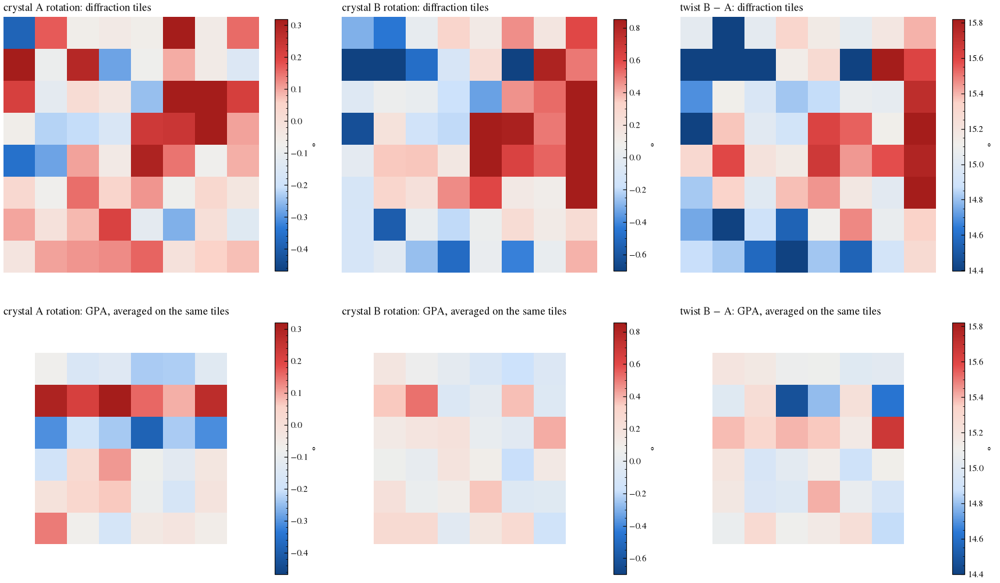

In [12]:
MAP_TILE = 4  # tile_cube tiles per map tile, each way: 128 x 128 probe positions
n_map = n_tiles // MAP_TILE
map_tiles = tiles_aligned.reshape(n_map, MAP_TILE, n_map, MAP_TILE, *tiles_aligned.shape[2:]).sum((1, 3))
tile_angles = np.empty((n_map, n_map, 2))  # detector angle of crystals A and B
start = time.perf_counter()
for row in range(n_map):
    for col in range(n_map):
        spots_map = np.where(outside_zero_beam, bragg_spots(map_tiles[row, col])[fit_window], 0)
        tile_fit, _ = fit_two_lattices(spots_map, kx_det, ky_det, diffraction_fit[1:3], diffraction_fit[3:5])
        tile_angles[row, col] = tile_fit[2], tile_fit[4]
print(f'{n_map * n_map} tile fits: {time.perf_counter() - start:.0f} s')

# Detector angles -> rotation in the scan frame (a mirror reverses the sense of rotation), relative to the PACBED fit.
sense = -1 if mirror else 1
tile_rotation = [sense * ((tile_angles[..., lattice] - diffraction_fit[2 + 2 * lattice] + 45) % 90 - 45) for lattice in range(2)]
tile_twist = image_twist + tile_rotation[1] - tile_rotation[0]
gpa_tiled = [image.reshape(n_map, N_COLUMNS // n_map, n_map, N_COLUMNS // n_map).mean((1, 3)) for image in (*gpa_rotation, gpa_twist)]
inner_tiles = np.isfinite(gpa_tiled[0])  # tiles inside the GPA frame (the frame is exactly one tile wide)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for k, (name, from_diffraction, from_image) in enumerate(
    [
        ('crystal A rotation', tile_rotation[0], gpa_tiled[0]),
        ('crystal B rotation', tile_rotation[1], gpa_tiled[1]),
        ('twist B − A', tile_twist, gpa_tiled[2]),
    ]
):
    middle_value = np.median(from_image[inner_tiles])
    limit = np.percentile(abs(np.concatenate([from_image[inner_tiles], from_diffraction[inner_tiles]]) - middle_value), 95)
    for row, (source, image) in enumerate([('diffraction tiles', from_diffraction), ('GPA, averaged on the same tiles', from_image)]):
        shown = axes[row, k].imshow(image, cmap=DIVERGING, vmin=middle_value - limit, vmax=middle_value + limit)
        fig.colorbar(shown, ax=axes[row, k], shrink=0.8, label='°')
        axes[row, k].set(title=f'{name}: {source}')
        no_grid(axes[row, k])
    r = np.corrcoef(from_diffraction[inner_tiles], from_image[inner_tiles])[0, 1]
    print(
        f'{name:>18} ({inner_tiles.sum()} inner tiles): diffraction mean {from_diffraction[inner_tiles].mean():+.2f}°, rms {from_diffraction[inner_tiles].std():.2f}°; GPA rms {from_image[inner_tiles].std():.2f}°; correlation {r:+.2f}'
    )
plt.tight_layout()
plt.show()

* On 128 × 128-position tiles, the two methods agree that nothing changes. The diffraction tiles scatter by 0.44° rms in
  the twist and GPA by 0.22°, and the two maps do not correlate (r = 0.15, from 36 inner tiles). Neither sees a
  tile-to-tile change above its own noise. For diffraction that noise is ~0.4° at 39 M electrons per tile, set mostly by
  crystal B's weak spots.
* The tile maps are relative to the PACBED and image fits, so their mean twist (15.09°) is not a separate measurement.

So the two crystals are **rotated by 15.1° against each other, uniformly across the 13–16 nm field to within ~0.3°**. That
is the precision of GPA here; scan distortion, not the crystals, sets what is left.

## 8. Summary, and saving the results

In [13]:
np.savez_compressed(
    work_directory / 'moire_rotation.npz',
    disk_edge=np.stack([edge_x, edge_y]),
    disk_com=np.stack([com_x, com_y]),
    pacbed=pacbed,
    bragg=bragg,
    diffraction_lattices=diffraction_fit[1:5],  # g_a (px), theta_a, g_b, theta_b, detector frame
    image_lattices=image_fit[1:5],  # g in cycles per field of view, theta, scan frame
    gpa_rotation=np.stack(gpa_rotation).astype(np.float32),  # crystal A, B: degrees from the mean, 1024 x 1024
    gpa_twist=gpa_twist.astype(np.float32),
    tile_rotation=np.stack(tile_rotation),  # crystal A, B: degrees from the mean, 128 x 128 positions per tile
)
print('saved', work_directory / 'moire_rotation.npz')

saved /Users/7c2/Documents/GitHub/Kronos/outputs/2026_10_08_NNO_200kV_15mrad/moire_rotation.npz


| step | choice | result | section |
|---|---|---|---|
| time bin | 4 × 4 probe positions = 4 lines × 60 µs | 256 × 256 patterns of 38 k electrons; the 24-position lattice fringes sampled 6× per period | 2 |
| cubes | one 9-minute pass: zero beam at b = 4 in 2 × 2 px; 32 × 32-position tiles at full detector resolution | 540 + 210 MB, cached in `outputs/` | 3 |
| alignment | on the disk edge, sub-pixel | the disk moves 0.2 px rms; the 1.2 px center-of-mass signal is intensity inside the disk | 4 |
| probe deconvolution | PACBED of the whole scan; Richardson–Lucy and edge matching | two square lattices, \|g\| = 29.4 px, rotated by 13.7° | 5 |
| image FFT | BF image, 1024 × 1024 | the same two lattices, 23.9-position period, rotated by 15.0°; moiré 91.8 positions; detector mirrored against the scan | 6 |
| rotation map | GPA (55-position resolution) and diffraction tiles (128 positions) | twist 15.1°, uniform to ~0.3° rms; local rotations ≤ 0.2–0.3°, below shear and noise | 7 |

`outputs/<run>/moire_rotation.npz` holds both disk-position maps, the PACBED and Bragg-spot map, both lattice fits, the GPA
rotation and twist maps, and the tile rotations.

**Things to keep in mind**

* The detector is mirrored against the scan (section 6). Any analysis that compares a direction on the detector with a
  direction in the scan has to apply that mirror and the 79° rotation.
* GPA is blind within ~128 positions of the image border, and the scan-disturbance bands show up as false rotation.
* The absolute scale depends on the convergence angle (section 6); the twist and the moiré do not.